# 032 — Repeated splits using the exact notebook-03 target logic

This notebook repeats the ZeBRA / genomic / combined comparison over many randomized
train/test partitions while preserving the target construction used by
`03_COMBINED_CLASSIFIERS.ipynb`.

## Exact target logic copied from 03

For each target, notebook 03:

1. starts from `ILD_TOP_DRIVERS_DATA.csv`;
2. left-merges the rephenotype table;
3. converts the target to numeric;
4. assigns **missing target values to 0**;
5. left-merges ZeBRA `predicted_risk`;
6. retains rows with non-missing `predicted_risk`.

Thus blank target cells are treated as controls. This is essential for reproducing
the ~0.80 ZeBRA AUC reported by notebook 03.

## Models

For every randomized outer split:

- **ZeBRA:** raw `predicted_risk` → ROC/AUC directly. No classifier.
- **Genomic:** LightGBM using genomic features only.
- **Combined:** LightGBM using genomic features + `predicted_risk`.

The outer split uses 40% train / 60% held-out test, matching notebook 03.

For the two learned models only, hyperparameter selection is done by inner stratified
cross-validation inside the 40% training partition. ZeBRA is never fitted or tuned.

## SHAP

SHAP is computed on each outer-test partition for the genomic and combined models.
Split-level mean absolute SHAP values are aggregated to obtain mean, median, maximum,
empirical split bounds, and bootstrap confidence bounds.

In [1]:
import os
import json
import secrets
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

N_REPEATS = 10
TRAIN_SIZE = 0.40
INNER_CV_FOLDS = 3
N_PARAM_TRIALS = 15

MAX_SHAP_PATIENTS = 2000
N_SHAP_BOOT = 1000
PARTIAL_AUC_MAX_FPR = 0.05

BASE_DATA_FILE = "ILD_TOP_DRIVERS_DATA.csv"
TARGET_FILE = "REPHENOTYPES FOR IC.csv"
PRED_FILE = "PREDICTIONS_52W_PRED_WINDOW.parquet"

ROOT_OUT = Path("./RESULTS/032_REPEATED_SPLITS_03_TARGET_LOGIC")
ROOT_OUT.mkdir(parents=True, exist_ok=True)

print("Train fraction:", TRAIN_SIZE)
print("Test fraction:", 1 - TRAIN_SIZE)
print("Repeats:", N_REPEATS)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


Train fraction: 0.4
Test fraction: 0.6
Repeats: 10


## Helper functions

In [2]:
def raw_partial_auc(y_true, score, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(y_true, score, drop_intermediate=False)
    keep = fpr < max_fpr
    fk, tk = fpr[keep], tpr[keep]
    t_at = np.interp(max_fpr, fpr, tpr)
    fk = np.r_[fk, max_fpr]
    tk = np.r_[tk, t_at]
    return float(np.trapz(tk, fk))


def auc_record(target_name, repeat, split_seed, model_name, y_true, score):
    return {
        "target_name": target_name,
        "repeat": repeat,
        "split_seed": int(split_seed),
        "model": model_name,
        "n_test": int(len(y_true)),
        "n_pos_test": int(np.asarray(y_true).sum()),
        "auc": float(roc_auc_score(y_true, score)),
        "partial_auc_fpr_0_05_raw": raw_partial_auc(
            y_true, score, PARTIAL_AUC_MAX_FPR
        ),
        "average_precision": float(
            average_precision_score(y_true, score)
        ),
    }


def parameter_space():
    return {
        "n_estimators": [50, 100, 200, 400, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.12],
        "num_leaves": [7, 15, 31, 63, 127],
        "max_depth": [-1, 3, 5, 7, 10, 14],
        "min_child_samples": [10, 20, 40, 80, 150],
        "subsample": [0.60, 0.75, 0.90, 1.0],
        "colsample_bytree": [0.40, 0.60, 0.80, 1.0],
        "reg_alpha": [0.0, 0.01, 0.10, 0.50, 1.0],
        "reg_lambda": [0.0, 0.10, 0.50, 1.0, 5.0],
        "min_split_gain": [0.0, 0.01, 0.10, 0.50],
        "max_bin": [63, 127, 255, 511],
    }


def fit_lgbm_inner_cv(X, y, param_seed, cv_seed, model_seed):
    X = X.reset_index(drop=True)
    y = np.asarray(y).astype(int)

    cv = StratifiedKFold(
        n_splits=INNER_CV_FOLDS,
        shuffle=True,
        random_state=int(cv_seed),
    )
    folds = list(cv.split(X, y))

    trials = ParameterSampler(
        parameter_space(),
        n_iter=N_PARAM_TRIALS,
        random_state=int(param_seed),
    )

    best_auc = -np.inf
    best_params = None

    for params in trials:
        fold_aucs = []

        for fi, (tr, va) in enumerate(folds):
            yy = y[tr]
            n_pos = max(int((yy == 1).sum()), 1)
            n_neg = max(int((yy == 0).sum()), 1)
            spw = n_neg / n_pos

            m = LGBMClassifier(
                **params,
                objective="binary",
                scale_pos_weight=spw,
                subsample_freq=1,
                n_jobs=-1,
                random_state=(int(model_seed) + fi + 1) % (2**31 - 1),
                verbosity=-1,
            )
            m.fit(X.iloc[tr], yy)
            p = m.predict_proba(X.iloc[va])[:, 1]
            fold_aucs.append(roc_auc_score(y[va], p))

        cv_auc = float(np.mean(fold_aucs))

        if cv_auc > best_auc:
            best_auc = cv_auc
            best_params = dict(params)

    n_pos = max(int((y == 1).sum()), 1)
    n_neg = max(int((y == 0).sum()), 1)

    final = LGBMClassifier(
        **best_params,
        objective="binary",
        scale_pos_weight=n_neg / n_pos,
        subsample_freq=1,
        n_jobs=-1,
        random_state=int(model_seed),
        verbosity=-1,
    )
    final.fit(X, y)

    return final, best_params, best_auc


def positive_class_shap(model, X):
    exp = shap.TreeExplainer(model)

    try:
        v = exp.shap_values(X, check_additivity=False)
    except TypeError:
        v = exp.shap_values(X)

    if isinstance(v, list):
        v = v[1] if len(v) > 1 else v[0]

    v = np.asarray(v)

    if v.ndim == 3:
        if v.shape[-1] == 2:
            v = v[:, :, 1]
        elif v.shape[0] == 2:
            v = v[1]

    if v.shape != X.shape:
        raise ValueError(f"Unexpected SHAP shape {v.shape}; X shape {X.shape}")

    return v


def split_shap(model, X_test, target, repeat, split_seed, model_name):
    sample_seed = secrets.randbits(31)
    Xs = X_test.sample(
        n=min(MAX_SHAP_PATIENTS, len(X_test)),
        random_state=sample_seed,
    )
    v = positive_class_shap(model, Xs)

    return pd.DataFrame({
        "target_name": target,
        "repeat": repeat,
        "split_seed": int(split_seed),
        "model": model_name,
        "feature": Xs.columns,
        "mean_abs_shap": np.abs(v).mean(axis=0),
        "n_shap_patients": len(Xs),
    })


def auc_summary(df):
    return (
        df.groupby(["target_name", "model"])["auc"]
        .agg(
            n_repeats="size",
            mean="mean",
            sd="std",
            median="median",
            min="min",
            max="max",
        )
        .reset_index()
    )


def shap_summary(df):
    rng = np.random.default_rng()
    rows = []

    for (target, model, feature), sub in df.groupby(
        ["target_name", "model", "feature"], sort=False
    ):
        x = sub["mean_abs_shap"].dropna().to_numpy(float)
        if len(x) == 0:
            continue

        boot_mean = np.empty(N_SHAP_BOOT)
        boot_max = np.empty(N_SHAP_BOOT)

        for b in range(N_SHAP_BOOT):
            xb = rng.choice(x, len(x), replace=True)
            boot_mean[b] = xb.mean()
            boot_max[b] = xb.max()

        rows.append({
            "target_name": target,
            "model": model,
            "feature": feature,
            "n_splits": len(x),
            "mean_importance": x.mean(),
            "median_importance": np.median(x),
            "max_importance": x.max(),
            "empirical_q025": np.quantile(x, 0.025),
            "empirical_q975": np.quantile(x, 0.975),
            "bootstrap_mean_ci_low": np.quantile(boot_mean, 0.025),
            "bootstrap_mean_ci_high": np.quantile(boot_mean, 0.975),
            "bootstrap_max_ci_low": np.quantile(boot_max, 0.025),
            "bootstrap_max_ci_high": np.quantile(boot_max, 0.975),
        })

    return pd.DataFrame(rows)

## Load the same inputs as notebook 03

In [3]:
BASE_DATA = pd.read_csv(BASE_DATA_FILE).drop(
    columns=["target"], errors="ignore"
)

NEW_TARGETS = (
    pd.read_csv(TARGET_FILE)
    .replace({"N": 0, "Y": 1, "y": 1, "n": 0, "na": np.nan})
    .rename(columns={"arb_person_id": "patient_id"})
)

PREDS = pd.read_parquet(PRED_FILE)

TARGET_NAMES = [
    c for c in NEW_TARGETS.columns
    if c != "patient_id"
]

print("BASE_DATA rows:", len(BASE_DATA))
print("Prediction rows:", len(PREDS))
print("Prediction unique patients:", PREDS["patient_id"].nunique())
print("Prediction duplicate rows beyond first:", PREDS["patient_id"].duplicated().sum())

print("\nTargets:")
for t in TARGET_NAMES:
    print(" -", t)

BASE_DATA rows: 19651
Prediction rows: 19519
Prediction unique patients: 12882
Prediction duplicate rows beyond first: 6636

Targets:
 - FILD or FILA ADJUDICATED
 - NONFIBROTIC ILD ADJUDICATED
 - NON FIBROTIC ILA ADJUDICATED


## Verify exact notebook-03 target construction

The critical lines below intentionally mirror notebook 03:

```python
DATA["target"] = pd.to_numeric(DATA["target"], errors="coerce").fillna(0).astype(int)
DATA = DATA[DATA["predicted_risk"].notnull()].copy()
```

The sanity split uses `random_state=1321` and should reproduce the ZeBRA result from 03.

In [4]:
SANITY = []

for TARGET_NAME in TARGET_NAMES:

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[["patient_id", TARGET_NAME]].rename(
                columns={TARGET_NAME: "target"}
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[["patient_id", "predicted_risk"]],
            on="patient_id",
            how="left",
        )
    )

    # EXACT NOTEBOOK-03 TARGET LOGIC
    DATA["target"] = (
        pd.to_numeric(DATA["target"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # EXACT NOTEBOOK-03 FILTER
    DATA = DATA[
        DATA["predicted_risk"].notnull()
    ].copy()

    X = DATA.drop(columns=["patient_id", "target"])
    y = DATA["target"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        train_size=0.40,
        stratify=y,
        random_state=1321,
    )

    auc03 = roc_auc_score(
        y_val,
        X_val["predicted_risk"],
    )

    SANITY.append({
        "target_name": TARGET_NAME,
        "n_total": len(DATA),
        "n_positive_total": int(y.sum()),
        "n_validation": len(y_val),
        "n_positive_validation": int(y_val.sum()),
        "zebra_auc_exact_03_split": float(auc03),
    })

SANITY = pd.DataFrame(SANITY)
SANITY.to_csv(
    ROOT_OUT / "sanity_exact_03_target_logic.csv",
    index=False,
)

display(SANITY)

,target_name,n_total,n_positive_total,n_validation,n_positive_validation,zebra_auc_exact_03_split
0,FILD or FILA ADJUDICATED,12882,271,7730,163,0.835301
1,NONFIBROTIC ILD ADJUDICATED,12882,30,7730,18,0.871571
2,NON FIBROTIC ILA ADJUDICATED,12882,77,7730,46,0.840895


## Repeated randomized outer splits

No fixed split seed is used. Every repeat saves the entropy-generated seed used for
the outer split.

In [5]:
ALL_AUC = []
ALL_SHAP = []
ALL_PARAMS = []

for TARGET_NAME in TARGET_NAMES:

    print("\n" + "=" * 110)
    print(TARGET_NAME)
    print("=" * 110)

    TDIR = ROOT_OUT / TARGET_NAME
    TDIR.mkdir(parents=True, exist_ok=True)

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[["patient_id", TARGET_NAME]].rename(
                columns={TARGET_NAME: "target"}
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[["patient_id", "predicted_risk"]],
            on="patient_id",
            how="left",
        )
    )

    # EXACT NOTEBOOK-03 TARGET LOGIC
    DATA["target"] = (
        pd.to_numeric(DATA["target"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # EXACT NOTEBOOK-03 FILTER
    DATA = DATA[
        DATA["predicted_risk"].notnull()
    ].copy()

    X_combined = DATA.drop(columns=["patient_id", "target"])
    X_genomic = X_combined.drop(columns=["predicted_risk"])
    y = DATA["target"].to_numpy()

    print(
        f"N={len(DATA):,}; positives={y.sum():,}; "
        f"genomic features={X_genomic.shape[1]:,}"
    )

    target_auc = []
    target_shap_frames = []

    for repeat in tqdm(
        range(1, N_REPEATS + 1),
        desc=f"{TARGET_NAME}: repeats",
    ):
        split_seed = secrets.randbits(31)
        cv_seed = secrets.randbits(31)

        tr, te = train_test_split(
            np.arange(len(DATA)),
            train_size=TRAIN_SIZE,
            stratify=y,
            random_state=split_seed,
        )

        yt = y[tr]
        ye = y[te]

        Xgt = X_genomic.iloc[tr]
        Xge = X_genomic.iloc[te]

        Xct = X_combined.iloc[tr]
        Xce = X_combined.iloc[te]

        # ZeBRA: DIRECT raw score. No LightGBM.
        zebra_score = Xce["predicted_risk"].to_numpy(dtype=float)

        genomic_model, gp, gcv = fit_lgbm_inner_cv(
            Xgt,
            yt,
            param_seed=secrets.randbits(31),
            cv_seed=cv_seed,
            model_seed=secrets.randbits(31),
        )

        combined_model, cp, ccv = fit_lgbm_inner_cv(
            Xct,
            yt,
            param_seed=secrets.randbits(31),
            cv_seed=cv_seed,
            model_seed=secrets.randbits(31),
        )

        genomic_score = genomic_model.predict_proba(Xge)[:, 1]
        combined_score = combined_model.predict_proba(Xce)[:, 1]

        recs = [
            auc_record(
                TARGET_NAME, repeat, split_seed,
                "zebra", ye, zebra_score
            ),
            auc_record(
                TARGET_NAME, repeat, split_seed,
                "genomic", ye, genomic_score
            ),
            auc_record(
                TARGET_NAME, repeat, split_seed,
                "combined", ye, combined_score
            ),
        ]

        target_auc.extend(recs)
        ALL_AUC.extend(recs)

        ALL_PARAMS.extend([
            {
                "target_name": TARGET_NAME,
                "repeat": repeat,
                "model": "genomic",
                "split_seed": int(split_seed),
                "inner_cv_auc": gcv,
                "params_json": json.dumps(gp, sort_keys=True),
            },
            {
                "target_name": TARGET_NAME,
                "repeat": repeat,
                "model": "combined",
                "split_seed": int(split_seed),
                "inner_cv_auc": ccv,
                "params_json": json.dumps(cp, sort_keys=True),
            },
        ])

        gs = split_shap(
            genomic_model, Xge, TARGET_NAME,
            repeat, split_seed, "genomic"
        )
        cs = split_shap(
            combined_model, Xce, TARGET_NAME,
            repeat, split_seed, "combined"
        )

        target_shap_frames.extend([gs, cs])
        ALL_SHAP.extend([gs, cs])

        # checkpoint after every repeat
        pd.DataFrame(target_auc).to_csv(
            TDIR / "auc_by_split_CHECKPOINT.csv",
            index=False,
        )
        pd.concat(
            target_shap_frames,
            ignore_index=True,
        ).to_csv(
            TDIR / "shap_by_split_CHECKPOINT.csv",
            index=False,
        )

    pd.DataFrame(target_auc).to_csv(
        TDIR / "auc_by_split.csv",
        index=False,
    )

    pd.concat(
        target_shap_frames,
        ignore_index=True,
    ).to_csv(
        TDIR / "shap_by_split.csv",
        index=False,
    )


FILD or FILA ADJUDICATED
N=12,882; positives=271; genomic features=1,746


FILD or FILA ADJUDICATED: repeats:   0%|          | 0/10 [00:00<?, ?it/s]


NONFIBROTIC ILD ADJUDICATED
N=12,882; positives=30; genomic features=1,746


NONFIBROTIC ILD ADJUDICATED: repeats:   0%|          | 0/10 [00:00<?, ?it/s]


NON FIBROTIC ILA ADJUDICATED
N=12,882; positives=77; genomic features=1,746


NON FIBROTIC ILA ADJUDICATED: repeats:   0%|          | 0/10 [00:00<?, ?it/s]

## AUC distribution summaries

In [6]:
AUC_DF = pd.DataFrame(ALL_AUC)
AUC_DF.to_csv(
    ROOT_OUT / "auc_all_targets_by_split.csv",
    index=False,
)

AUC_SUMMARY = auc_summary(AUC_DF)
AUC_SUMMARY.to_csv(
    ROOT_OUT / "auc_distribution_summary.csv",
    index=False,
)

wide = AUC_DF.pivot_table(
    index=["target_name", "repeat", "split_seed"],
    columns="model",
    values="auc",
).reset_index()

DELTA = []
for target, sub in wide.groupby("target_name"):
    for a, b in [
        ("combined", "zebra"),
        ("genomic", "zebra"),
        ("combined", "genomic"),
    ]:
        d = (sub[a] - sub[b]).to_numpy()
        DELTA.append({
            "target_name": target,
            "comparison": f"{a} - {b}",
            "n_repeats": len(d),
            "mean_delta_auc": d.mean(),
            "median_delta_auc": np.median(d),
            "q025": np.quantile(d, 0.025),
            "q975": np.quantile(d, 0.975),
            "fraction_gt_zero": np.mean(d > 0),
        })

DELTA = pd.DataFrame(DELTA)
DELTA.to_csv(
    ROOT_OUT / "paired_auc_delta_summary.csv",
    index=False,
)

pd.DataFrame(ALL_PARAMS).to_csv(
    ROOT_OUT / "best_params_by_split.csv",
    index=False,
)

display(AUC_SUMMARY)
display(DELTA)

,target_name,model,n_repeats,mean,sd,median,min,max
0,FILD or FILA ADJUDICATED,combined,10,0.822390,0.010158,0.822147,0.807934,0.843559
1,FILD or FILA ADJUDICATED,genomic,10,0.538851,0.024708,0.533244,0.502848,0.588660
2,FILD or FILA ADJUDICATED,zebra,10,0.837633,0.011621,0.835574,0.824246,0.857752
3,NON FIBROTIC ILA ADJUDICATED,combined,10,0.721585,0.060784,0.734993,0.573948,0.793071
4,NON FIBROTIC ILA ADJUDICATED,genomic,10,0.477524,0.058495,0.482146,0.387154,0.562937
5,NON FIBROTIC ILA ADJUDICATED,zebra,10,0.857468,0.015470,0.854045,0.838278,0.877444
6,NONFIBROTIC ILD ADJUDICATED,combined,10,0.561724,0.145315,0.608075,0.254654,0.727553
7,NONFIBROTIC ILD ADJUDICATED,genomic,10,0.450371,0.050203,0.452462,0.342208,0.520171
8,NONFIBROTIC ILD ADJUDICATED,zebra,10,0.863046,0.021197,0.860155,0.839096,0.907583


,target_name,comparison,n_repeats,mean_delta_auc,median_delta_auc,q025,q975,fraction_gt_zero
0,FILD or FILA ADJUDICATED,combined - zebra,10,-0.015243,-0.010662,-0.039511,-0.004095,0.0
1,FILD or FILA ADJUDICATED,genomic - zebra,10,-0.298782,-0.302566,-0.329184,-0.248423,0.0
2,FILD or FILA ADJUDICATED,combined - genomic,10,0.283539,0.286765,0.236033,0.311954,1.0
3,NON FIBROTIC ILA ADJUDICATED,combined - zebra,10,-0.135883,-0.133934,-0.247047,-0.059996,0.0
4,NON FIBROTIC ILA ADJUDICATED,genomic - zebra,10,-0.379944,-0.369718,-0.474039,-0.288756,0.0
5,NON FIBROTIC ILA ADJUDICATED,combined - genomic,10,0.244061,0.227083,0.119422,0.351178,1.0
6,NONFIBROTIC ILD ADJUDICATED,combined - zebra,10,-0.301322,-0.246762,-0.557285,-0.139255,0.0
7,NONFIBROTIC ILD ADJUDICATED,genomic - zebra,10,-0.412675,-0.402520,-0.496557,-0.351038,0.0
8,NONFIBROTIC ILD ADJUDICATED,combined - genomic,10,0.111353,0.119228,-0.158796,0.329983,0.8


## Plot AUC distributions for all three phenotype contexts

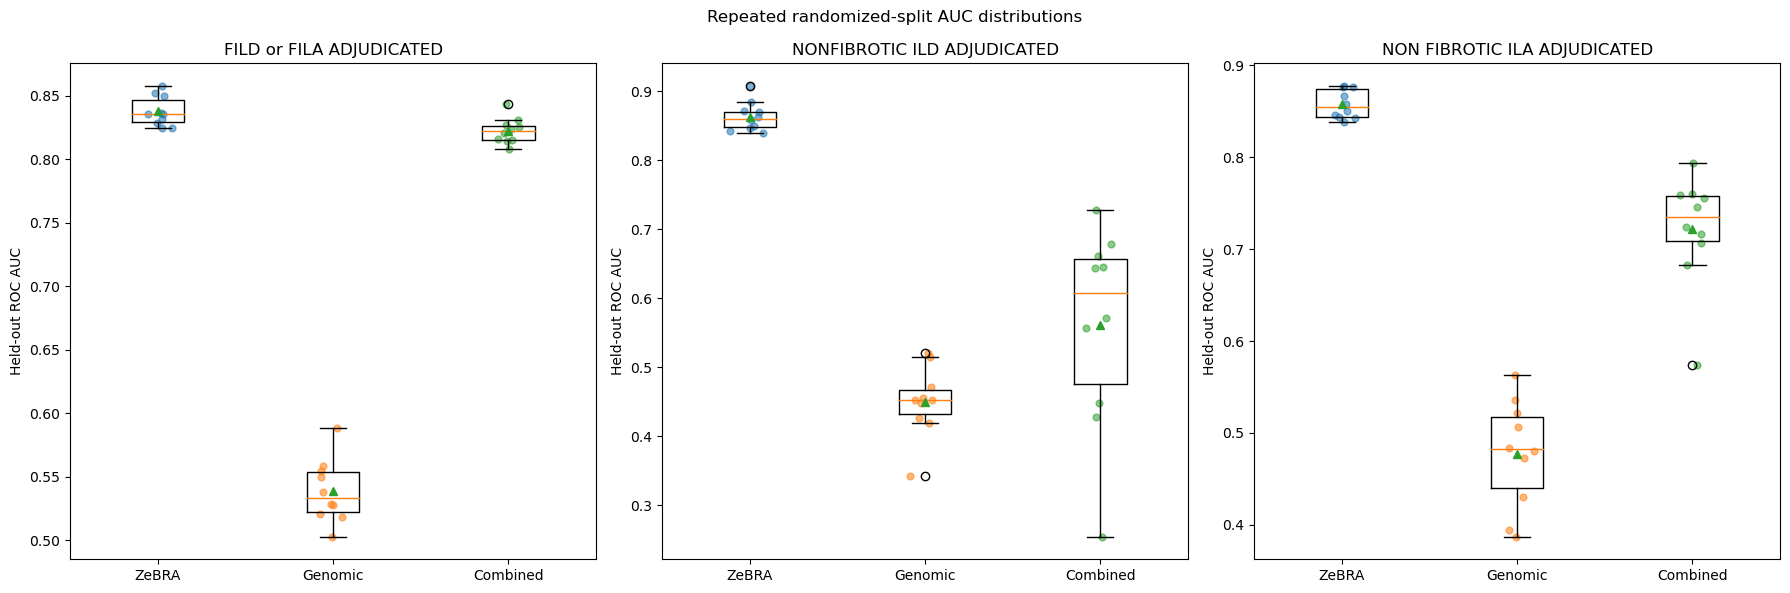

In [7]:
MODEL_ORDER = ["zebra", "genomic", "combined"]

fig, axes = plt.subplots(
    1, len(TARGET_NAMES),
    figsize=(6 * len(TARGET_NAMES), 6),
)

if len(TARGET_NAMES) == 1:
    axes = [axes]

for ax, target in zip(axes, TARGET_NAMES):
    sub = AUC_DF[AUC_DF["target_name"] == target]

    vals = [
        sub.loc[sub["model"] == m, "auc"].to_numpy()
        for m in MODEL_ORDER
    ]

    ax.boxplot(
        vals,
        labels=["ZeBRA", "Genomic", "Combined"],
        showmeans=True,
    )

    rng = np.random.default_rng()
    for j, x in enumerate(vals, 1):
        ax.scatter(
            rng.normal(j, 0.04, len(x)),
            x,
            alpha=0.55,
            s=24,
        )

    ax.set_title(target)
    ax.set_ylabel("Held-out ROC AUC")

fig.suptitle("Repeated randomized-split AUC distributions")
fig.tight_layout()
fig.savefig(
    ROOT_OUT / "auc_distributions_three_targets.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Aggregate SHAP importance across splits

In [11]:
SHAP_DF = pd.concat(ALL_SHAP, ignore_index=True)

SHAP_DF.to_csv(
    ROOT_OUT / "shap_all_targets_by_split.csv",
    index=False,
)

SHAP_SUMMARY = shap_summary(SHAP_DF)

SHAP_SUMMARY.to_csv(
    ROOT_OUT / "shap_feature_stability_summary.csv",
    index=False,
)

display(
    SHAP_SUMMARY
    .sort_values(
        ["target_name", "model", "max_importance"],
        ascending=[True, True, False],
    )
    .groupby(["target_name", "model"], group_keys=False)
    .head(20)
)

,target_name,model,feature,n_splits,mean_importance,median_importance,max_importance,empirical_q025,empirical_q975,bootstrap_mean_ci_low,bootstrap_mean_ci_high,bootstrap_max_ci_low,bootstrap_max_ci_high
3492,FILD or FILA ADJUDICATED,combined,predicted_risk,10,0.748335,0.730861,1.054211,0.442190,1.013409,0.646193,0.847945,0.860831,1.054211
2851,FILD or FILA ADJUDICATED,combined,rs35705950.1_G_1,10,0.034562,0.005999,0.194278,0.000197,0.173190,0.004288,0.079547,0.010191,0.194278
1775,FILD or FILA ADJUDICATED,combined,rs3131520_C_2,10,0.039757,0.004741,0.190891,0.000000,0.184288,0.004154,0.083899,0.015182,0.190891
2128,FILD or FILA ADJUDICATED,combined,rs4680134_C_1,10,0.029738,0.001017,0.185739,0.000000,0.153385,0.004097,0.069967,0.030763,0.185739
3179,FILD or FILA ADJUDICATED,combined,rs12446021_G_2,10,0.040866,0.023743,0.184636,0.000000,0.163164,0.013206,0.073437,0.034824,0.184636
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4155,NONFIBROTIC ILD ADJUDICATED,genomic,rs2076295_T_2,10,40.707065,0.009177,404.653128,0.000000,314.043208,0.044362,121.616473,0.212631,404.653128
4821,NONFIBROTIC ILD ADJUDICATED,genomic,JHU_14.95067217_C_2,10,40.171608,0.000000,401.538072,0.000000,311.213196,0.003094,120.479223,0.010315,401.538072
4098,NONFIBROTIC ILD ADJUDICATED,genomic,rs2228972_G_2,10,38.567697,0.009762,384.492324,0.000000,298.099280,0.050392,115.454546,0.476539,384.492324
5142,NONFIBROTIC ILD ADJUDICATED,genomic,rs302837_A_2,10,32.698779,0.070161,320.918425,0.002530,249.760935,0.137147,97.231572,0.992647,320.918425


## Plot maximum SHAP importance with bootstrap bounds

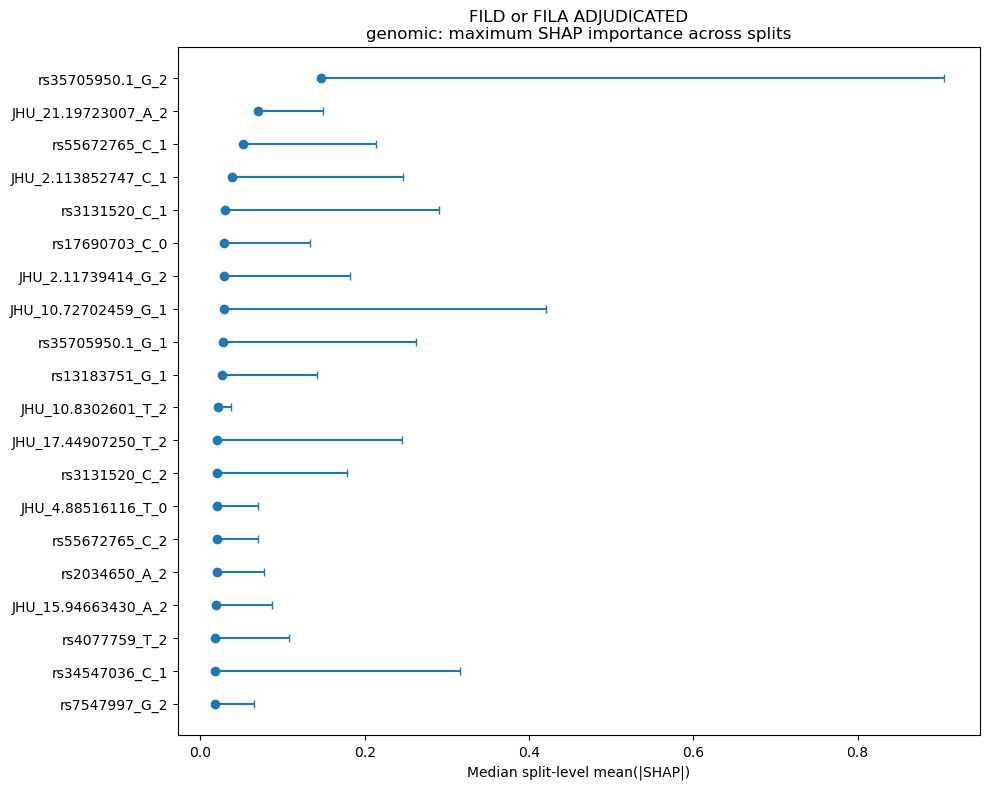

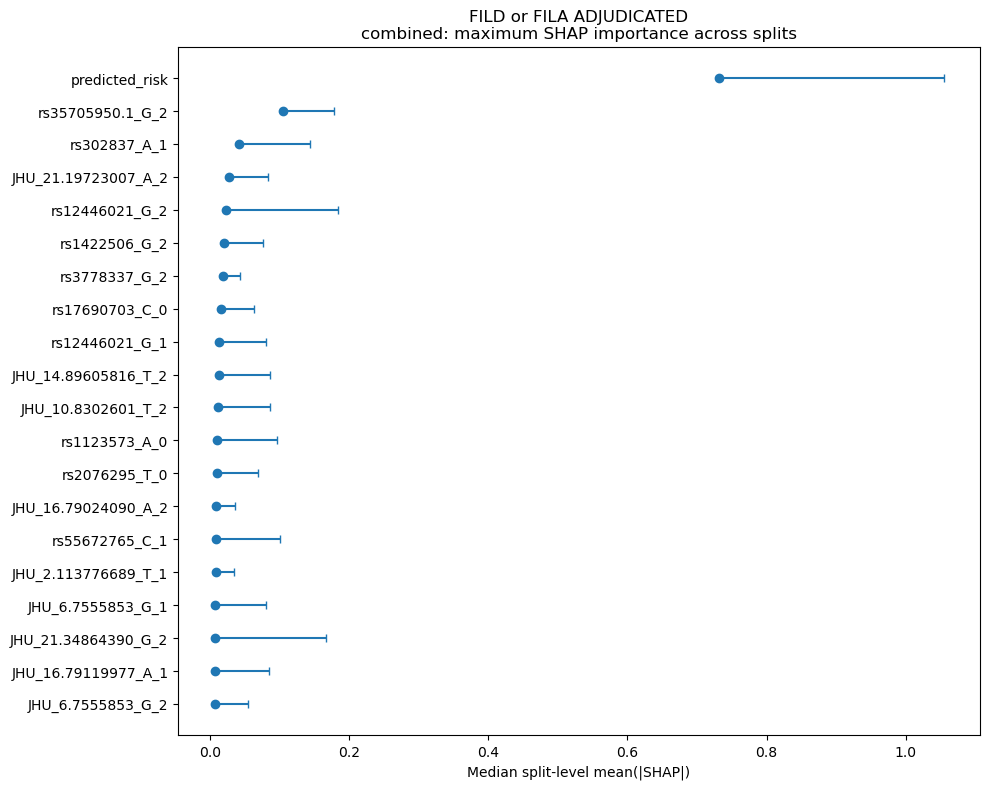

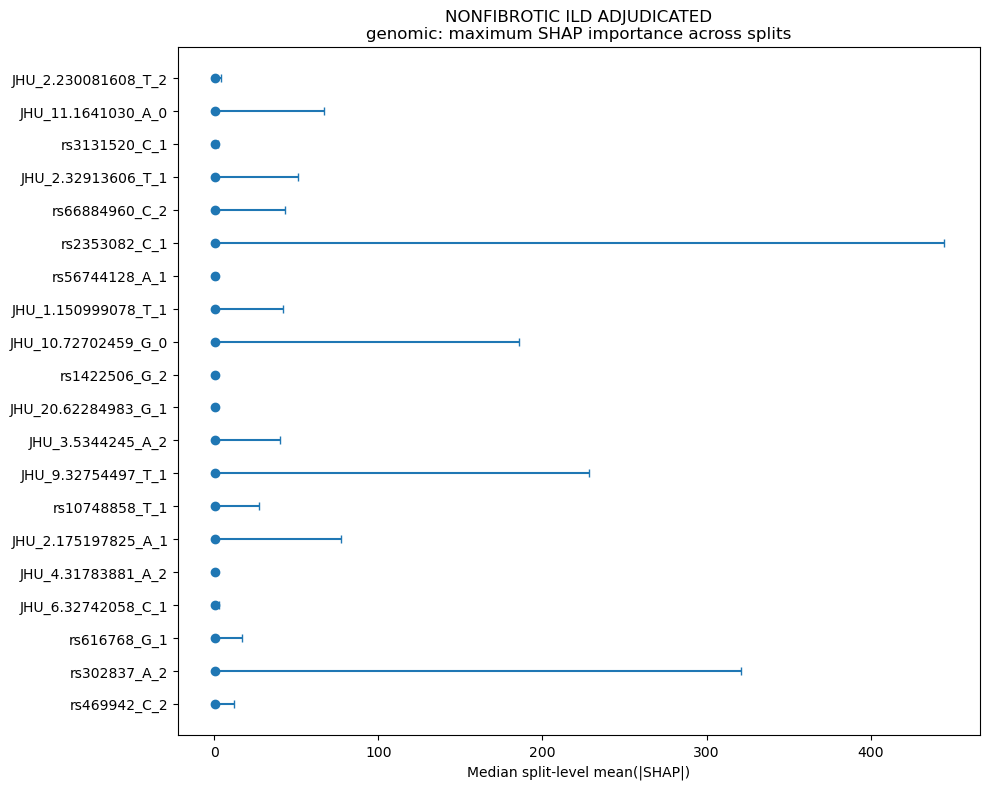

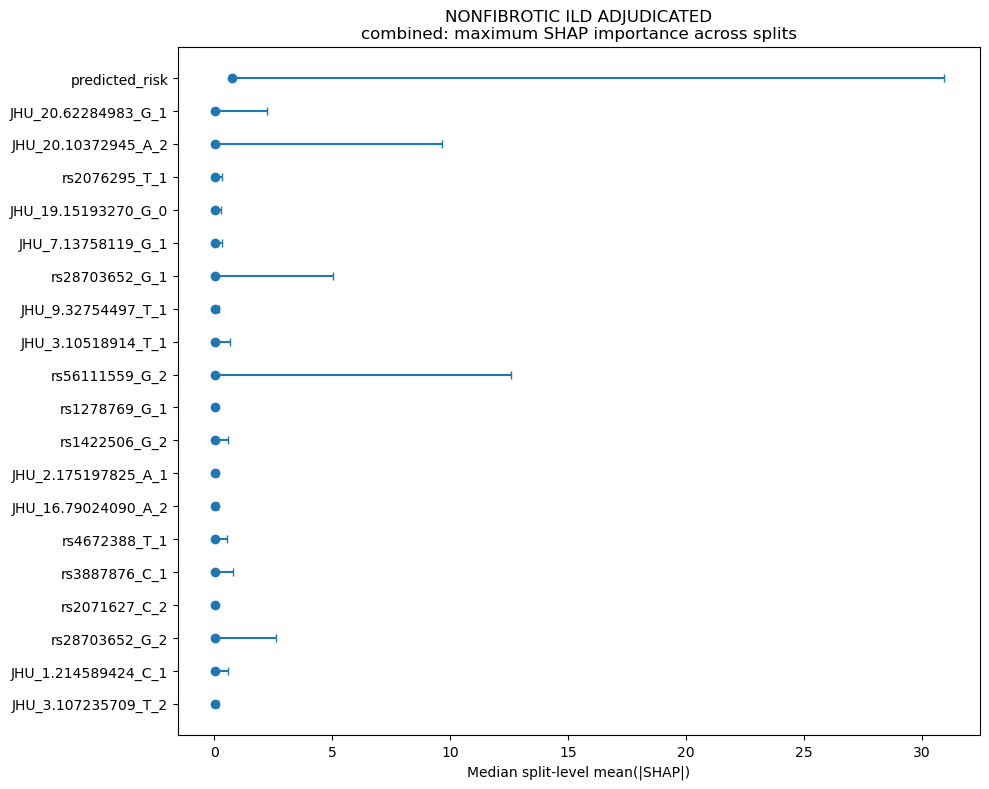

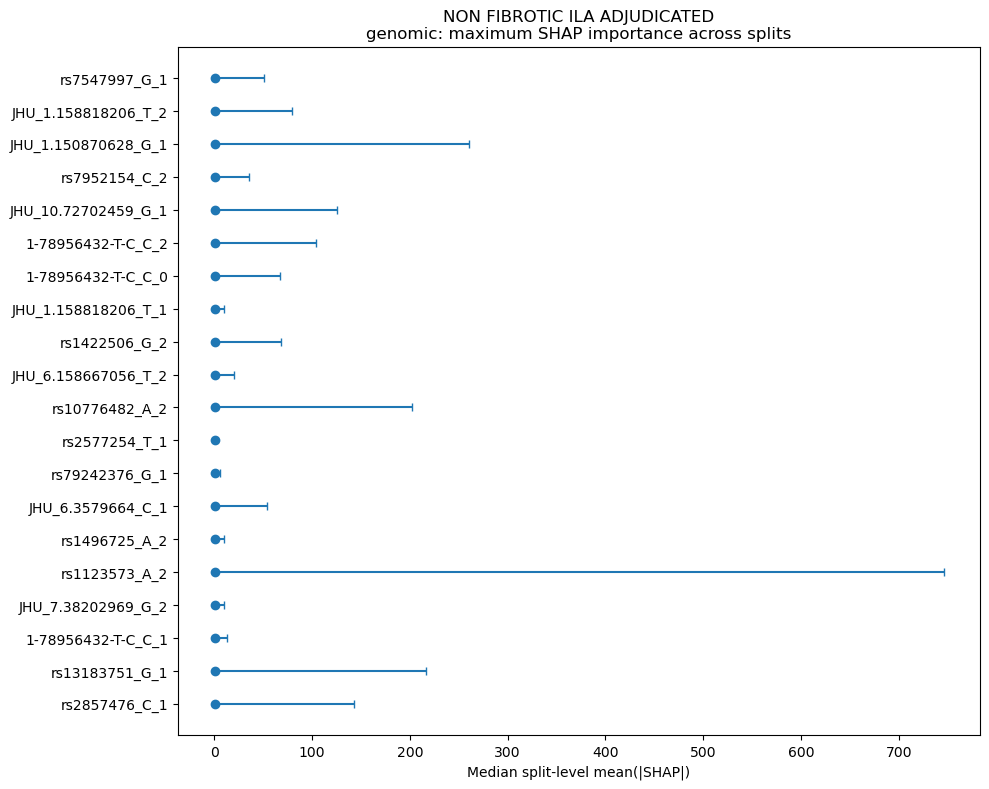

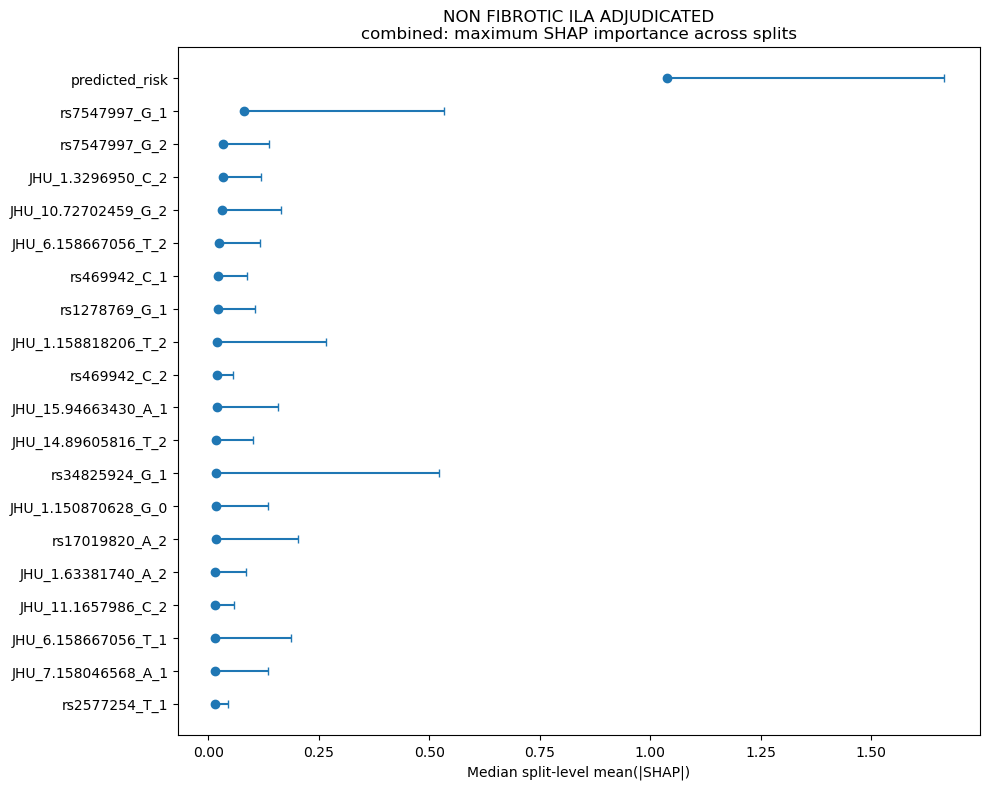

In [12]:
for target in TARGET_NAMES:
    for model in ["genomic", "combined"]:

        sub = (
            SHAP_SUMMARY[
                (SHAP_SUMMARY["target_name"] == target)
                & (SHAP_SUMMARY["model"] == model)
            ]
            .sort_values("median_importance", ascending=False)
            .head(20)
            .sort_values("median_importance")
        )

        x = sub["median_importance"].to_numpy()
        lo = sub["bootstrap_max_ci_low"].to_numpy()
        hi = sub["bootstrap_max_ci_high"].to_numpy()

        fig, ax = plt.subplots(figsize=(10, 8))

        ax.errorbar(
            x,
            np.arange(len(sub)),
            xerr=[
                np.maximum(x - lo, 0),
                np.maximum(hi - x, 0),
            ],
            fmt="o",
            capsize=3,
        )

        ax.set_yticks(np.arange(len(sub)))
        ax.set_yticklabels(sub["feature"])
        ax.set_xlabel("Median split-level mean(|SHAP|)")
        ax.set_title(
            f"{target}\n{model}: maximum SHAP importance across splits"
        )

        fig.tight_layout()
        fig.savefig(
            ROOT_OUT / target / f"shap_max_ci_{model}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

## Top-20 SHAP recurrence across splits

In [13]:
ranked = SHAP_DF.copy()

ranked["rank"] = (
    ranked.groupby(
        ["target_name", "model", "repeat"]
    )["mean_abs_shap"]
    .rank(method="min", ascending=False)
)

RECURRENCE = (
    ranked[ranked["rank"] <= 20]
    .groupby(["target_name", "model", "feature"])
    .agg(
        top20_split_count=("repeat", "nunique"),
        mean_rank_when_top20=("rank", "mean"),
        max_mean_abs_shap=("mean_abs_shap", "max"),
    )
    .reset_index()
)

RECURRENCE["fraction_splits_top20"] = (
    RECURRENCE["top20_split_count"] / N_REPEATS
)

RECURRENCE.to_csv(
    ROOT_OUT / "shap_top20_recurrence.csv",
    index=False,
)

display(
    RECURRENCE
    .sort_values(
        ["target_name", "model", "fraction_splits_top20", "max_mean_abs_shap"],
        ascending=[True, True, False, False],
    )
    .groupby(["target_name", "model"], group_keys=False)
    .head(25)
)

,target_name,model,feature,top20_split_count,mean_rank_when_top20,max_mean_abs_shap,fraction_splits_top20
63,FILD or FILA ADJUDICATED,combined,predicted_risk,10,1.000000,1.054211,1.0
106,FILD or FILA ADJUDICATED,combined,rs35705950.1_G_2,8,4.250000,0.177553,0.8
97,FILD or FILA ADJUDICATED,combined,rs302837_A_1,6,11.833333,0.143120,0.6
71,FILD or FILA ADJUDICATED,combined,rs1123573_A_0,4,15.500000,0.096203,0.4
110,FILD or FILA ADJUDICATED,combined,rs4077759_T_2,4,7.500000,0.092507,0.4
...,...,...,...,...,...,...,...
865,NONFIBROTIC ILD ADJUDICATED,genomic,rs1423029_A_0,2,13.000000,19.544720,0.2
805,NONFIBROTIC ILD ADJUDICATED,genomic,JHU_2.230081608_T_2,2,10.500000,3.841206,0.2
902,NONFIBROTIC ILD ADJUDICATED,genomic,rs469942_C_2,2,17.500000,2.677032,0.2
861,NONFIBROTIC ILD ADJUDICATED,genomic,rs12658068_G_1,2,4.500000,2.242170,0.2
